# Urban Pulse — Modeling: Combined (XGBoost & Random Forest)

> **File**: `modeling_combine.ipynb`  
> **Tujuan**: Menggabungkan pipeline pemodelan **XGBoost** (berdasarkan model terbaik di `modeling (1).ipynb`) dan **Random Forest** (berdasarkan model terbaik di `randomforest.ipynb`). Notebook ini melakukan pelatihan, pencarian threshold, perbandingan metrik evaluasi secara berdampingan, dan analisis interpretabilitas (SHAP) untuk membandingkan karakteristik kedua model sebelum ekspor final.

---

## 🔬 Penjelasan Setiap Cell

Notebook ini menyajikan perbandingan *head-to-head* antara XGBoost (boosting) dan Random Forest (bagging) untuk memetakan kawasan kumuh (*slum mapping*).

### Cell 1 — Import Library

**Tujuan**: Mengimpor semua library Python untuk pemodelan ensemble, analisis evaluasi metrik, visualisasi perbandingan, dan analisis interpretabilitas (SHAP).

In [1]:
from __future__ import annotations

import json
from datetime import date
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import shap

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
RANDOM_STATE = 42

C:\Users\Fauzi\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Cell 2 — Konfigurasi

**Tujuan**: Menentukan path direktori data, penyimpanan model untuk kedua algoritma, target kolom label, target batas recall, dan parameter visualisasi.

In [2]:
PROCESSED_DIR = Path("data/processed")
DATA_PATH = PROCESSED_DIR / "features_buildings_clean.csv"
FEATURE_COLS_PATH = PROCESSED_DIR / "feature_columns.csv"

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

XGB_MODEL_PATH = MODELS_DIR / "slum_xgb_pipeline.joblib"
XGB_METADATA_PATH = MODELS_DIR / "model_metadata.json"

RF_MODEL_PATH = MODELS_DIR / "slum_rf_pipeline.joblib"
RF_METADATA_PATH = MODELS_DIR / "model_rf_metadata.json"

TARGET_COL = "slum"
CITY_COL = "city"
TEST_SIZE = 0.2
TARGET_RECALL = 0.80

### Cell 3 — Load Data

**Tujuan**: Membaca dataset bersih dan daftar fitur model yang sudah disaring dari kebocoran data (*data leakage*).

In [3]:
df = pd.read_csv(DATA_PATH)
feature_cols = pd.read_csv(FEATURE_COLS_PATH)["feature_name"].tolist()

print(f"Dataset: {df.shape}")
print(f"Jumlah fitur model: {len(feature_cols)}")
print(f"Distribusi kelas: slum={int(df[TARGET_COL].sum())} ({df[TARGET_COL].mean()*100:.1f}%) / non-slum={int((df[TARGET_COL]==0).sum())}")

Dataset: (830, 49)
Jumlah fitur model: 41
Distribusi kelas: slum=118 (14.2%) / non-slum=712


### Cell 4 — Definisi Model XGBoost & Random Forest

**Tujuan**: Membuat fungsi instansiasi model XGBoost (dari `modeling (1).ipynb`) dan Random Forest (dari `randomforest.ipynb`) dengan hyperparameter optimal masing-masing.

In [4]:
def make_xgb(scale_pos_weight=1.0, random_state=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=random_state,
        n_jobs=-1,
    )

def make_rf(random_state=RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=random_state,
        n_jobs=-1,
    )

### Cell 5 — Evaluasi LOCO Default (Threshold 0.5)

**Tujuan**: Menjalankan evaluasi Leave-One-City-Out untuk kedua model menggunakan nilai threshold default 0.5 sebagai baseline komparasi.

In [5]:
def run_loco_evaluation_combined(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    cities = sorted(df[CITY_COL].unique())
    rows = []

    for city in cities:
        train_mask = df[CITY_COL] != city
        test_mask = df[CITY_COL] == city

        X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, TARGET_COL]
        X_test, y_test = df.loc[test_mask, feature_cols], df.loc[test_mask, TARGET_COL]

        # 1. XGBoost
        pos, neg = y_train.sum(), len(y_train) - y_train.sum()
        spw = neg / max(pos, 1)
        model_xgb = make_xgb(scale_pos_weight=spw).fit(X_train, y_train)
        y_pred_xgb = model_xgb.predict(X_test)
        y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
        
        # 2. Random Forest
        model_rf = make_rf().fit(X_train, y_train)
        y_pred_rf = model_rf.predict(X_test)
        y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

        rows.append({
            "city": city,
            "xgb_recall": recall_score(y_test, y_pred_xgb, zero_division=0),
            "xgb_precision": precision_score(y_test, y_pred_xgb, zero_division=0),
            "xgb_roc_auc": roc_auc_score(y_test, y_proba_xgb) if y_test.sum() > 0 else np.nan,
            "rf_recall": recall_score(y_test, y_pred_rf, zero_division=0),
            "rf_precision": precision_score(y_test, y_pred_rf, zero_division=0),
            "rf_roc_auc": roc_auc_score(y_test, y_proba_rf) if y_test.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows)

loco_df = run_loco_evaluation_combined(df, feature_cols)
print("Hasil LOCO per kota (threshold default 0.5):")
print(loco_df.round(3))
print("\nRata-rata LOCO (Threshold 0.5):")
print(loco_df.mean(numeric_only=True).round(3))

Hasil LOCO per kota (threshold default 0.5):
        city  xgb_recall  xgb_precision  xgb_roc_auc  rf_recall  rf_precision  rf_roc_auc
0      ambon       0.600          0.643        0.855      0.533         0.571       0.848
1        dki       0.903          0.230        0.484      0.935         0.234       0.514
2    kebumen       0.000          0.000        0.767      0.000         0.000       0.776
3  samarinda       0.571          0.286        0.679      0.786         0.324       0.713

Rata-rata LOCO (Threshold 0.5):
xgb_recall       0.519
xgb_precision    0.290
xgb_roc_auc      0.696
rf_recall        0.564
rf_precision     0.282
rf_roc_auc       0.713
dtype: float64


### Cell 6 — Random Stratified Split & Threshold Tuning

**Tujuan**: Menjalankan Stratified Split 80/20 untuk menyelaraskan parameter kedua model, lalu mencari threshold optimal masing-masing agar mencapai Recall $\ge 0.80$.

In [6]:
strat_key = df[CITY_COL].astype(str) + "_" + df[TARGET_COL].astype(str)
X = df[feature_cols]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=strat_key
)

# Training XGBoost & Random Forest pada training split
pos, neg = y_train.sum(), len(y_train) - y_train.sum()
xgb_split = make_xgb(scale_pos_weight=neg/max(pos, 1)).fit(X_train, y_train)
y_proba_xgb_split = xgb_split.predict_proba(X_test)[:, 1]

rf_split = make_rf().fit(X_train, y_train)
y_proba_rf_split = rf_split.predict_proba(X_test)[:, 1]

def find_threshold_for_recall(y_true, y_proba, target_recall=TARGET_RECALL):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_threshold, best_precision = 0.0, -1.0
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        r = recall_score(y_true, pred, zero_division=0)
        p = precision_score(y_true, pred, zero_division=0)
        if r >= target_recall and p > best_precision:
            best_threshold, best_precision = t, p
    return best_threshold

best_threshold_xgb = find_threshold_for_recall(y_test, y_proba_xgb_split)
best_threshold_rf = find_threshold_for_recall(y_test, y_proba_rf_split)

# Ensemble threshold
y_proba_ens_split = (y_proba_xgb_split + y_proba_rf_split) / 2.0
best_threshold_ens = find_threshold_for_recall(y_test, y_proba_ens_split)

print(f"Threshold optimal XGBoost     : {best_threshold_xgb:.4f}")
print(f"Threshold optimal Random Forest : {best_threshold_rf:.4f}")
print(f"Threshold optimal Ensemble      : {best_threshold_ens:.4f}")

Threshold optimal XGBoost     : 0.0900
Threshold optimal Random Forest : 0.4100
Threshold optimal Ensemble      : 0.2500


### Cell 7 — Validasi LOCO pada Threshold Terpilih

**Tujuan**: Menguji ketahanan model pada skema LOCO menggunakan threshold optimal yang sudah di-tuning.

In [7]:
def run_loco_with_tuned_thresholds(df, feature_cols, thresh_xgb, thresh_rf, thresh_ens):
    cities = sorted(df[CITY_COL].unique())
    rows = []
    for city in cities:
        train_mask = df[CITY_COL] != city
        test_mask = df[CITY_COL] == city
        X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, TARGET_COL]
        X_test, y_test = df.loc[test_mask, feature_cols], df.loc[test_mask, TARGET_COL]

        # XGBoost
        pos, neg = y_train.sum(), len(y_train) - y_train.sum()
        xgb = make_xgb(scale_pos_weight=neg/max(pos, 1)).fit(X_train, y_train)
        y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
        y_pred_xgb = (y_proba_xgb >= thresh_xgb).astype(int)

        # Random Forest
        rf = make_rf().fit(X_train, y_train)
        y_proba_rf = rf.predict_proba(X_test)[:, 1]
        y_pred_rf = (y_proba_rf >= thresh_rf).astype(int)

        # Ensemble
        y_proba_ens = (y_proba_xgb + y_proba_rf) / 2.0
        y_pred_ens = (y_proba_ens >= thresh_ens).astype(int)

        rows.append({
            "city": city,
            "xgb_recall": recall_score(y_test, y_pred_xgb, zero_division=0),
            "xgb_precision": precision_score(y_test, y_pred_xgb, zero_division=0),
            "rf_recall": recall_score(y_test, y_pred_rf, zero_division=0),
            "rf_precision": precision_score(y_test, y_pred_rf, zero_division=0),
            "ens_recall": recall_score(y_test, y_pred_ens, zero_division=0),
            "ens_precision": precision_score(y_test, y_pred_ens, zero_division=0),
        })
    return pd.DataFrame(rows)

loco_tuned_df = run_loco_with_tuned_thresholds(df, feature_cols, best_threshold_xgb, best_threshold_rf, best_threshold_ens)
print("Hasil LOCO per kota pada threshold hasil tuning:")
print(loco_tuned_df.round(3))
print("\nRata-rata LOCO pada threshold hasil tuning:")
print(loco_tuned_df.mean(numeric_only=True).round(3))

Hasil LOCO per kota pada threshold hasil tuning:
        city  xgb_recall  xgb_precision  rf_recall  rf_precision  ens_recall  ens_precision
0      ambon       0.800          0.571      0.800         0.571       0.800          0.571
1        dki       0.984          0.235      0.935         0.228       0.968          0.232
2    kebumen       0.037          0.500      0.000         0.000       0.000          0.000
3  samarinda       1.000          0.333      0.857         0.324       0.857          0.316

Rata-rata LOCO pada threshold hasil tuning:
xgb_recall       0.705
xgb_precision    0.410
rf_recall        0.648
rf_precision     0.281
ens_recall       0.656
ens_precision    0.280
dtype: float64


### Cell 8 — Pelatihan Model Final & Perbandingan SHAP Global

**Tujuan**: Melatih model final XGBoost dan Random Forest pada seluruh dataset (830 baris), lalu menghitung kontribusi SHAP global masing-masing secara berdampingan.

In [8]:
# Model Final
pos_all, neg_all = y.sum(), len(y) - y.sum()
xgb_final = make_xgb(scale_pos_weight=neg_all/max(pos_all, 1)).fit(X, y)
rf_final = make_rf().fit(X, y)

# SHAP XGBoost
explainer_xgb = shap.TreeExplainer(xgb_final)
shap_xgb = explainer_xgb.shap_values(X)
if isinstance(shap_xgb, list):
    shap_xgb = shap_xgb[-1]

# SHAP Random Forest
explainer_rf = shap.TreeExplainer(rf_final)
shap_rf = explainer_rf.shap_values(X)
if isinstance(shap_rf, list):
    shap_rf = shap_rf[-1]
elif isinstance(shap_rf, np.ndarray) and shap_rf.ndim == 3:
    if shap_rf.shape[2] == 2:
        shap_rf = shap_rf[:, :, 1]
    elif shap_rf.shape[0] == 2:
        shap_rf = shap_rf[1, :, :]

# Hitung pentingnya fitur
imp_xgb = pd.Series(np.abs(shap_xgb).mean(axis=0), index=feature_cols).sort_values(ascending=False)
imp_rf = pd.Series(np.abs(shap_rf).mean(axis=0), index=feature_cols).sort_values(ascending=False)

imp_compare = pd.DataFrame({
    "XGB_Feature": imp_xgb.index,
    "XGB_SHAP": imp_xgb.values,
    "RF_Feature": imp_rf.index,
    "RF_SHAP": imp_rf.values,
})
print("Perbandingan Top 10 Fitur Global SHAP:")
print(imp_compare.head(10).round(4))

Perbandingan Top 10 Fitur Global SHAP:
                        XGB_Feature  XGB_SHAP                        RF_Feature  RF_SHAP
0                        b_coverage    0.3753            building_presence_mean   0.0347
1          building_presence_stdDev    0.3674                        b_coverage   0.0332
2                   ndbi_var_stdDev    0.3041          building_presence_stdDev   0.0325
3                       b_area_mean    0.2965                     b_density_km2   0.0251
4  building_fractional_count_stdDev    0.2736                   ndbi_var_stdDev   0.0194
5                         VV_stdDev    0.2659                      vv_vh_stdDev   0.0177
6                     dense_lowrise    0.2499                         VV_stdDev   0.0163
7                ndbi_contrast_mean    0.2381              building_height_mean   0.0152
8                       ndbi_stdDev    0.2300    building_fractional_count_mean   0.0149
9                     ndbi_ent_mean    0.2297  building_fractional_coun

### Cell 9 — Ekspor Kedua Model untuk Deployment

**Tujuan**: Mengekspor kedua file model terlatih (.joblib) beserta metadatanya agar bisa diakses backend secara modular.

In [9]:
# Simpan Model
joblib.dump(xgb_final, XGB_MODEL_PATH)
joblib.dump(rf_final, RF_MODEL_PATH)
print(f"XGBoost disimpan       -> {XGB_MODEL_PATH}")
print(f"Random Forest disimpan -> {RF_MODEL_PATH}")

# Fungsi ekspor metadata
def export_meta(model, path, model_type, threshold, metrics_dict, global_imp):
    metadata = {
        "model_file": path.name,
        "model_type": model_type,
        "threshold": round(float(threshold), 4),
        "threshold_selection_method": "max precision subject to recall >= 0.8 (random stratified split)",
        "feature_names": feature_cols,
        "n_features": len(feature_cols),
        "target_column": TARGET_COL,
        "cities": sorted(df[CITY_COL].unique().tolist()),
        "n_training_rows": int(len(df)),
        "class_balance": {
            "slum": int(y.sum()),
            "non_slum": int((y == 0).sum()),
            "pct_slum": round(float(y.mean() * 100), 2),
        },
        "validation_metrics": metrics_dict,
        "top_global_features": global_imp.head(10).round(4).to_dict(),
        "trained_on": str(date.today()),
    }
    with open(path, "w") as f:
        json.dump(metadata, f, indent=2)

# Perhitungan metrik split
y_pred_xgb_split = (y_proba_xgb_split >= best_threshold_xgb).astype(int)
y_pred_rf_split = (y_proba_rf_split >= best_threshold_rf).astype(int)

xgb_metrics = {
    "random_split": {
        "recall": round(float(recall_score(y_test, y_pred_xgb_split, zero_division=0)), 4),
        "precision": round(float(precision_score(y_test, y_pred_xgb_split, zero_division=0)), 4),
        "f1": round(float(f1_score(y_test, y_pred_xgb_split, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, y_proba_xgb_split)), 4),
    },
    "loco_at_threshold": {
        "recall_mean": round(float(loco_tuned_df["xgb_recall"].mean()), 4),
        "precision_mean": round(float(loco_tuned_df["xgb_precision"].mean()), 4),
    },
}

rf_metrics = {
    "random_split": {
        "recall": round(float(recall_score(y_test, y_pred_rf_split, zero_division=0)), 4),
        "precision": round(float(precision_score(y_test, y_pred_rf_split, zero_division=0)), 4),
        "f1": round(float(f1_score(y_test, y_pred_rf_split, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, y_proba_rf_split)), 4),
    },
    "loco_at_threshold": {
        "recall_mean": round(float(loco_tuned_df["rf_recall"].mean()), 4),
        "precision_mean": round(float(loco_tuned_df["rf_precision"].mean()), 4),
    },
}

export_meta(xgb_final, XGB_METADATA_PATH, "XGBClassifier", best_threshold_xgb, xgb_metrics, imp_xgb)
export_meta(rf_final, RF_METADATA_PATH, "RandomForestClassifier", best_threshold_rf, rf_metrics, imp_rf)
print("Metadata untuk kedua model berhasil diekspor!")

XGBoost disimpan       -> models\slum_xgb_pipeline.joblib
Random Forest disimpan -> models\slum_rf_pipeline.joblib
Metadata untuk kedua model berhasil diekspor!


### Cell 10 — Visualisasi Perbandingan Kinerja Spasial (Plots)

**Tujuan**: Menggambar visualisasi perbandingan metrik kinerja LOCO dan kurva ROC-AUC untuk mempermudah analisis performa model.

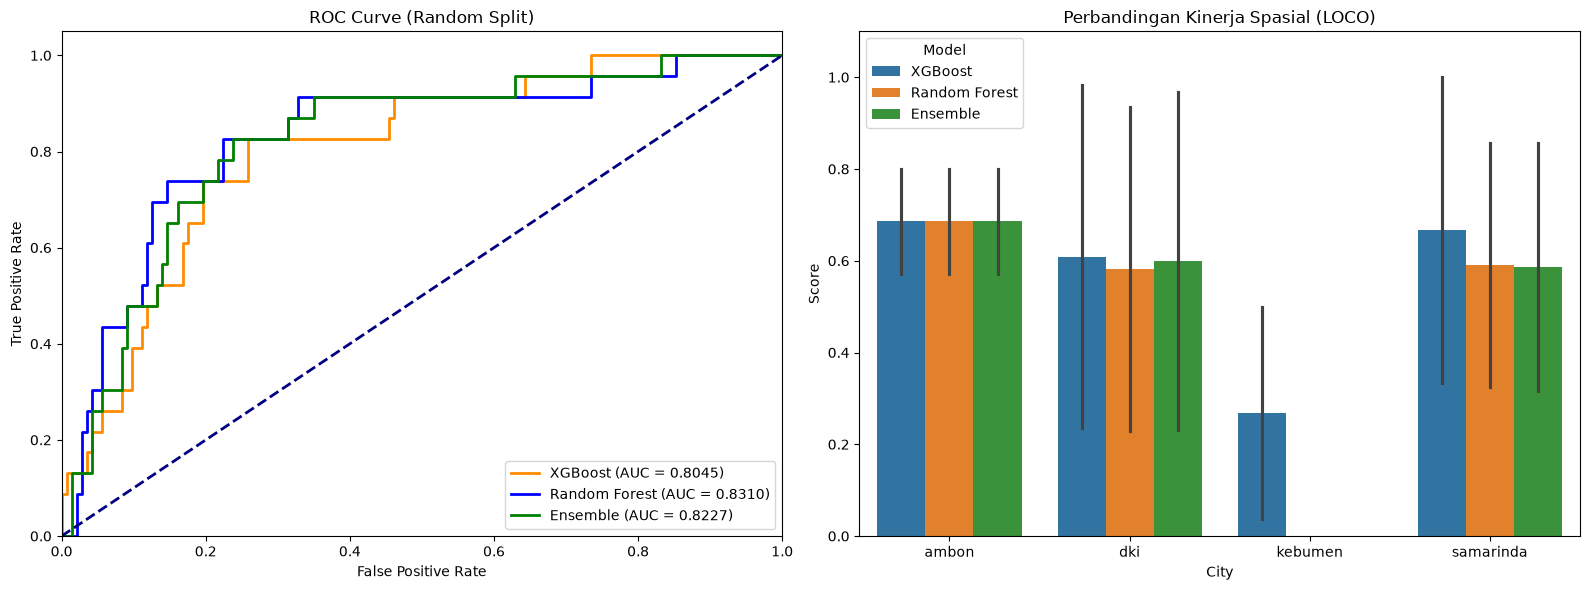

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Kurva ROC-AUC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb_split)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf_split)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_ens, tpr_ens, _ = roc_curve(y_test, y_proba_ens_split)
roc_auc_ens = auc(fpr_ens, tpr_ens)

axes[0].plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
axes[0].plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
axes[0].plot(fpr_ens, tpr_ens, color='green', lw=2, label=f'Ensemble (AUC = {roc_auc_ens:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Random Split)')
axes[0].legend(loc="lower right")

# 2. Perbandingan Kinerja LOCO (Recall & Precision)
loco_melt = loco_tuned_df.melt(id_vars=['city'], value_vars=[
    'xgb_recall', 'xgb_precision', 'rf_recall', 'rf_precision', 'ens_recall', 'ens_precision'
])
def get_model(var):
    if 'xgb' in var: return 'XGBoost'
    elif 'rf' in var: return 'Random Forest'
    else: return 'Ensemble'

loco_melt['Model'] = loco_melt['variable'].apply(get_model)
loco_melt['Metric'] = loco_melt['variable'].apply(lambda x: 'Recall' if 'recall' in x else 'Precision')

sns.barplot(data=loco_melt, x='city', y='value', hue='Model', ax=axes[1])
axes[1].set_title('Perbandingan Kinerja Spasial (LOCO)')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('City')
axes[1].set_ylim([0, 1.1])

plt.tight_layout()

# Ekspor grafik komparasi secara fisik ke folder models
plt.savefig("models/model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()